## Imports

In [6]:
import mosaique as mq
from concurrent.futures import ProcessPoolExecutor, as_completed
import itertools
import numpy as np
import pennylane as qml
import os
from mosaique.models.operation import OperationLayer
from tensorflow import keras

## Check GPU installation is working

In [7]:
import tensorflow as tf 
import tensorrt as trt

print(f' tensorflow version {tf.__version__}')

print(f' tensorrt version {trt.__version__}')

print(tf.config.list_physical_devices('GPU'))

 tensorflow version 2.18.0
 tensorrt version 10.7.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:

# Set the environment for asynchronous GPU usage
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'

In [9]:
def operation():
    dev = qml.device("default.qubit.tf", wires=4)
    @qml.qnode(dev, interface='tf')
    def cnot(inputs):
        inputs = inputs * np.pi
        qml.AngleEmbedding(inputs[:,...], wires=range(4), rotation='Y')

        qml.CNOT(wires=[0, 1])
        qml.CNOT(wires=[2, 3])

        # Measurement producing 4 classical output values
        return [qml.expval(qml.PauliZ(j)) for j in range(4)]
    return cnot


In [25]:
def preset():
    from tensorflow import keras
    mnist_dataset = keras.datasets.fashion_mnist
    # name of the folder where will save the filtered images for training
    tr_layer = mq.ConvolutionLayer4x4("results_fashion_train")
    # name of the folder where will save the filtered images for testing
    te_layer = mq.ConvolutionLayer4x4("results_fashion_test")
    #load the data set want to train
    (tr_images, tr_labels), (te_images, te_labels) = mnist_dataset.load_data()
    
    # tr_images = tr_images[:50:]
    # tr_labels = tr_labels[:50]
    # te_images = te_images[:10:]
    # te_labels = te_labels[:10]
    
    tr_layer.fit(tr_images)
    te_layer.fit(te_images)
    tr_images = tr_layer.transform(tr_images)
    te_images = te_layer.transform(te_images)
    return ((tr_layer, (tr_images, tr_labels)), (te_layer,(te_images, te_labels)))

with ProcessPoolExecutor() as executor:
    future = executor.submit(preset)

((train_layer, (train_images, train_labels)), (test_layer,(test_images, test_labels))) = future.result() #This blocks until the task completes

In [11]:

permutations = np.asarray(list(itertools.permutations(range(4))))

def pool(x, call, p, l):
    op = OperationLayer(call())
    predict = l.post_transform(op.pre_op.predict(x,batch_size=1000))
    l.save(predict, p)

In [12]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=train_images[:,:,p], call=operation, p=p, l=train_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [13]:
for j in range(3):
    with ProcessPoolExecutor(8) as executor:
        runner = {
            executor.submit(pool, x=test_images[:,:,p], call=operation, p=p, l=test_layer): p for p in permutations[8*j:8*(j+1)]
        }
        for future in as_completed(runner):
            runner.pop(future)

In [14]:
from keras.callbacks import CSVLogger

def run(tr_images, te_images, label):
    log_dir = train_layer.name + "/run/"
    log_file = train_layer.name + "/run/" + label
    os.makedirs(log_dir, exist_ok=True)
    
    csv_logger = CSVLogger(log_file)
    
    # tensorboard_callback = keras.callbacks.TensorBoard(
    #     log_dir=log_file,
    #     histogram_freq=1,
    #     write_graph=True,
    #     write_images=True,
    #     write_steps_per_second=True,
    #     update_freq='batch',
    #     profile_batch=1,
    #     embeddings_freq=1,
    #     embeddings_metadata=None
    # )
    q_model = keras.models.Sequential([
        keras.layers.Rescaling(scale=-1. / 127.5, offset=1),
        keras.layers.Flatten(),
        keras.layers.Dense(10, activation="softmax")
    ])
    q_model.compile(
        optimizer='adam',
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    q_history = q_model.fit(
        tr_images,
        train_labels,
        validation_data=(te_images, test_labels),
        batch_size=128,
        epochs=60,
        verbose=2,
        # callbacks=[tensorboard_callback]
        callbacks = csv_logger
    )

def model(variant, tr_layer, te_layer):
    tr_images = tr_layer.open(variant)
    te_images =  te_layer.open(variant)

    label = ''.join(map(str,variant))

    run(tr_images, te_images, label)

(10, 14, 14, 4)


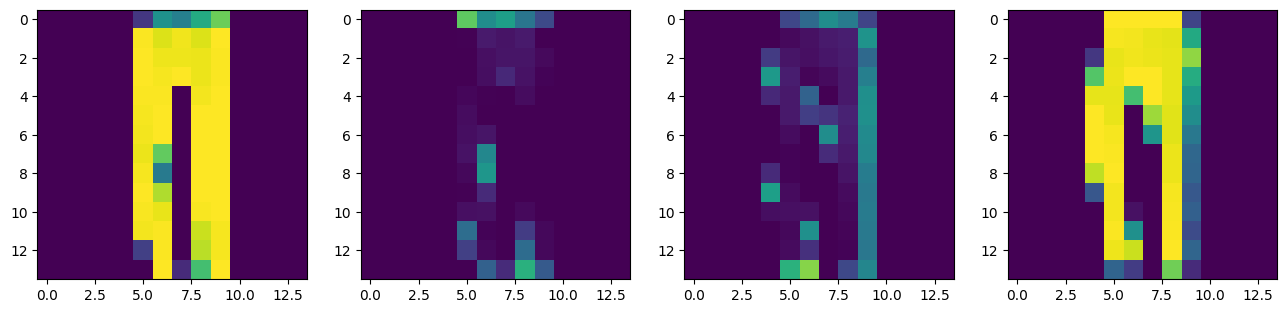

In [15]:
from matplotlib import pyplot as plt

print(test_layer.open([0,1,3,2]).shape)

post = test_layer.open([0,1,3,2])

_min, _max = np.amin(post), np.amax(post)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot all output channels for quantum cnot
for c in range(4):
    axes[c].imshow(post[2,:,:,c],vmin = _min, vmax = _max)

In [24]:

# for j in range(3):
#     with ProcessPoolExecutor(8) as executor:
#         runner = {
#             executor.submit(model,variant = p, tr_layer = train_layer, te_layer= test_layer): p for p in permutations[8*j:8*(j+1)]
#         }
#         for future in as_completed(runner):
#             runner.pop(future)

2025-01-24 08:39:29.835795: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:136] Non-OK-status: cuda::ToStatus(cuCtxSetCurrent(context_), "Failed setting context")
Status: INTERNAL: CUDA error: Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-01-24 08:39:29.835976: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:136] Non-OK-status: cuda::ToStatus(cuCtxSetCurrent(context_), "Failed setting context")
Status: INTERNAL: CUDA error: Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-01-24 08:39:29.836004: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:136] Non-OK-status: cuda::ToStatus(cuCtxSetCurrent(context_), "Failed setting context")
Status: INTERNAL: CUDA error: Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-01-24 08:39:29.836015: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:136] Non-OK-status: cuda::ToStatus(cuCtxSetCurrent(context_), "Failed s

In [17]:
for ind, variant  in enumerate(permutations):

    label = ''.join(map(str,variant))
    # print(ind, label)
    tr_images = train_layer.open(variant)
    te_images =  test_layer.open(variant)
    run(tr_images,te_images,label)

Epoch 1/60


I0000 00:00:1737668010.720658  832930 gpu_process_state.cc:201] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1737668010.722138  832930 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21985 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:8a:00.0, compute capability: 8.6
I0000 00:00:1737668011.453242  839681 service.cc:148] XLA service 0x7fe474004940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1737668011.453353  839681 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2025-01-24 08:33:31.484741: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1737668011.534876  839681 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-01-24 08:33:32.897919: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compi

1/1 - 4s - 4s/step - accuracy: 0.2000 - loss: 2.7024 - val_accuracy: 0.1000 - val_loss: 2.8019
Epoch 2/60
1/1 - 0s - 147ms/step - accuracy: 0.2000 - loss: 2.3644 - val_accuracy: 0.0000e+00 - val_loss: 2.4903
Epoch 3/60
1/1 - 0s - 140ms/step - accuracy: 0.2000 - loss: 2.1395 - val_accuracy: 0.0000e+00 - val_loss: 2.2992
Epoch 4/60
1/1 - 0s - 123ms/step - accuracy: 0.2800 - loss: 1.9802 - val_accuracy: 0.1000 - val_loss: 2.1836
Epoch 5/60
1/1 - 0s - 120ms/step - accuracy: 0.3400 - loss: 1.8439 - val_accuracy: 0.2000 - val_loss: 2.1255
Epoch 6/60
1/1 - 0s - 124ms/step - accuracy: 0.3800 - loss: 1.7244 - val_accuracy: 0.2000 - val_loss: 2.1063
Epoch 7/60
1/1 - 0s - 128ms/step - accuracy: 0.4000 - loss: 1.6192 - val_accuracy: 0.2000 - val_loss: 2.0934
Epoch 8/60
1/1 - 0s - 151ms/step - accuracy: 0.3800 - loss: 1.5178 - val_accuracy: 0.2000 - val_loss: 2.0616
Epoch 9/60
1/1 - 0s - 139ms/step - accuracy: 0.4400 - loss: 1.4133 - val_accuracy: 0.2000 - val_loss: 2.0063
Epoch 10/60
1/1 - 0s - 12

In [18]:
# run the network without filter

run(train_images,test_images,"NO-FILTER")

Epoch 1/60


2025-01-24 08:37:35.060720: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 152 bytes spill stores, 152 bytes spill loads

2025-01-24 08:37:35.222508: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 612 bytes spill stores, 528 bytes spill loads

2025-01-24 08:37:36.795802: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_32', 52 bytes spill stores, 52 bytes spill loads



1/1 - 4s - 4s/step - accuracy: 0.2000 - loss: 2.6413 - val_accuracy: 0.1000 - val_loss: 2.8013
Epoch 2/60
1/1 - 0s - 123ms/step - accuracy: 0.2400 - loss: 2.3448 - val_accuracy: 0.1000 - val_loss: 2.4973
Epoch 3/60
1/1 - 0s - 139ms/step - accuracy: 0.3000 - loss: 2.1114 - val_accuracy: 0.0000e+00 - val_loss: 2.2523
Epoch 4/60
1/1 - 0s - 138ms/step - accuracy: 0.3400 - loss: 1.9253 - val_accuracy: 0.1000 - val_loss: 2.0382
Epoch 5/60
1/1 - 0s - 159ms/step - accuracy: 0.4400 - loss: 1.7680 - val_accuracy: 0.1000 - val_loss: 1.8464
Epoch 6/60
1/1 - 0s - 138ms/step - accuracy: 0.4600 - loss: 1.6282 - val_accuracy: 0.4000 - val_loss: 1.6779
Epoch 7/60
1/1 - 0s - 125ms/step - accuracy: 0.4800 - loss: 1.4996 - val_accuracy: 0.5000 - val_loss: 1.5363
Epoch 8/60
1/1 - 0s - 124ms/step - accuracy: 0.5400 - loss: 1.3797 - val_accuracy: 0.5000 - val_loss: 1.4205
Epoch 9/60
1/1 - 0s - 139ms/step - accuracy: 0.6000 - loss: 1.2682 - val_accuracy: 0.5000 - val_loss: 1.3288
Epoch 10/60
1/1 - 0s - 139ms/

# Read Validation accuracy 
Now we will read from the csv and group the experiment validation for the last 30 epoch into the symmetries

In [19]:
# group the index of the permutation by the symmetry of the filter

diagonal_index = [4, 5, 8, 9, 14, 15, 18, 19]
vertical_index = [0, 1, 6, 7, 16, 17, 22, 23]
horizontal_index = [2, 3, 10, 11, 12, 13, 20, 21]

In [20]:
import pandas as pd

diagonal_val_accuracy = []
vertical_val_accuracy = []
horizontal_val_accuracy = []

for ind, variant  in enumerate(permutations):
    label = ''.join(map(str,variant))
    # print(label)
    file = train_layer.name + "/run/" + label
    # print(file)
    
    #read the csv file
    df = pd.read_csv(file)
    
    if ind in diagonal_index:
        diagonal_val_accuracy.append(df['val_accuracy'].tail(30).tolist())
        
    elif ind in vertical_index:
        vertical_val_accuracy.append(df['val_accuracy'].tail(30).tolist())
    
    elif ind in horizontal_index:
        horizontal_val_accuracy.append(df['val_accuracy'].tail(30).tolist())


In [21]:
# need to flatten the list to have all the data in a single list
diagonal_val_accuracy_flattened = [item for sublist in diagonal_val_accuracy for item in sublist]
vertical_val_accuracy_flattened = [item for sublist in vertical_val_accuracy for item in sublist]
horizontal_val_accuracy_flattened = [item for sublist in horizontal_val_accuracy for item in sublist]


In [22]:
file = train_layer.name + "/run/" + "NO-FILTER"
df = pd.read_csv(file)
no_fitler_val_accuracy = df['val_accuracy'].tail(30).tolist()

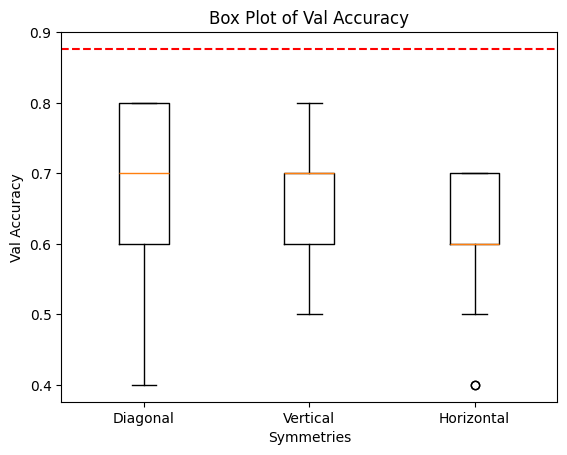

In [23]:
import matplotlib.pyplot as plt

# Combine the data into a list of lists
data = [diagonal_val_accuracy_flattened, vertical_val_accuracy_flattened, horizontal_val_accuracy_flattened]

# Define the labels for the box plot
labels_plot = ['Diagonal', 'Vertical', 'Horizontal']

# Create the box plot
plt.boxplot(data, labels=labels_plot)

# Calculate the mean value of the no_filter list
mean_no_filter = np.mean(no_fitler_val_accuracy)

# Add a horizontal line at the mean value of no_filter
plt.axhline(y= mean_no_filter, color='r', linestyle='--', label=f'Mean No Filter: {mean_no_filter:.2f}')


# Add title and labels
plt.title('Box Plot of Val Accuracy')
plt.xlabel('Symmetries')
plt.ylabel('Val Accuracy')

# Show the plot
plt.show()